In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter

In [51]:
df = pd.read_csv('A:/1 - DS phyton/учебные датасеты/cardiovascular_risk_dataset.csv')
df

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [52]:
df3 = df
df3 = df3.drop(['Patient_ID', 'heart_disease_risk_score'], axis = 1)
df3['smoking_status'] = df3['smoking_status'].map({'Current': 0, 'Former': 1, 'Never': 2})
df3['family_history_heart_disease'] = df3['family_history_heart_disease'].map({'No': 0, 'Yes': 1})
df3['risk_category'] = df3['risk_category'].map({'Low': 0, 'Medium': 1, 'High': 2})


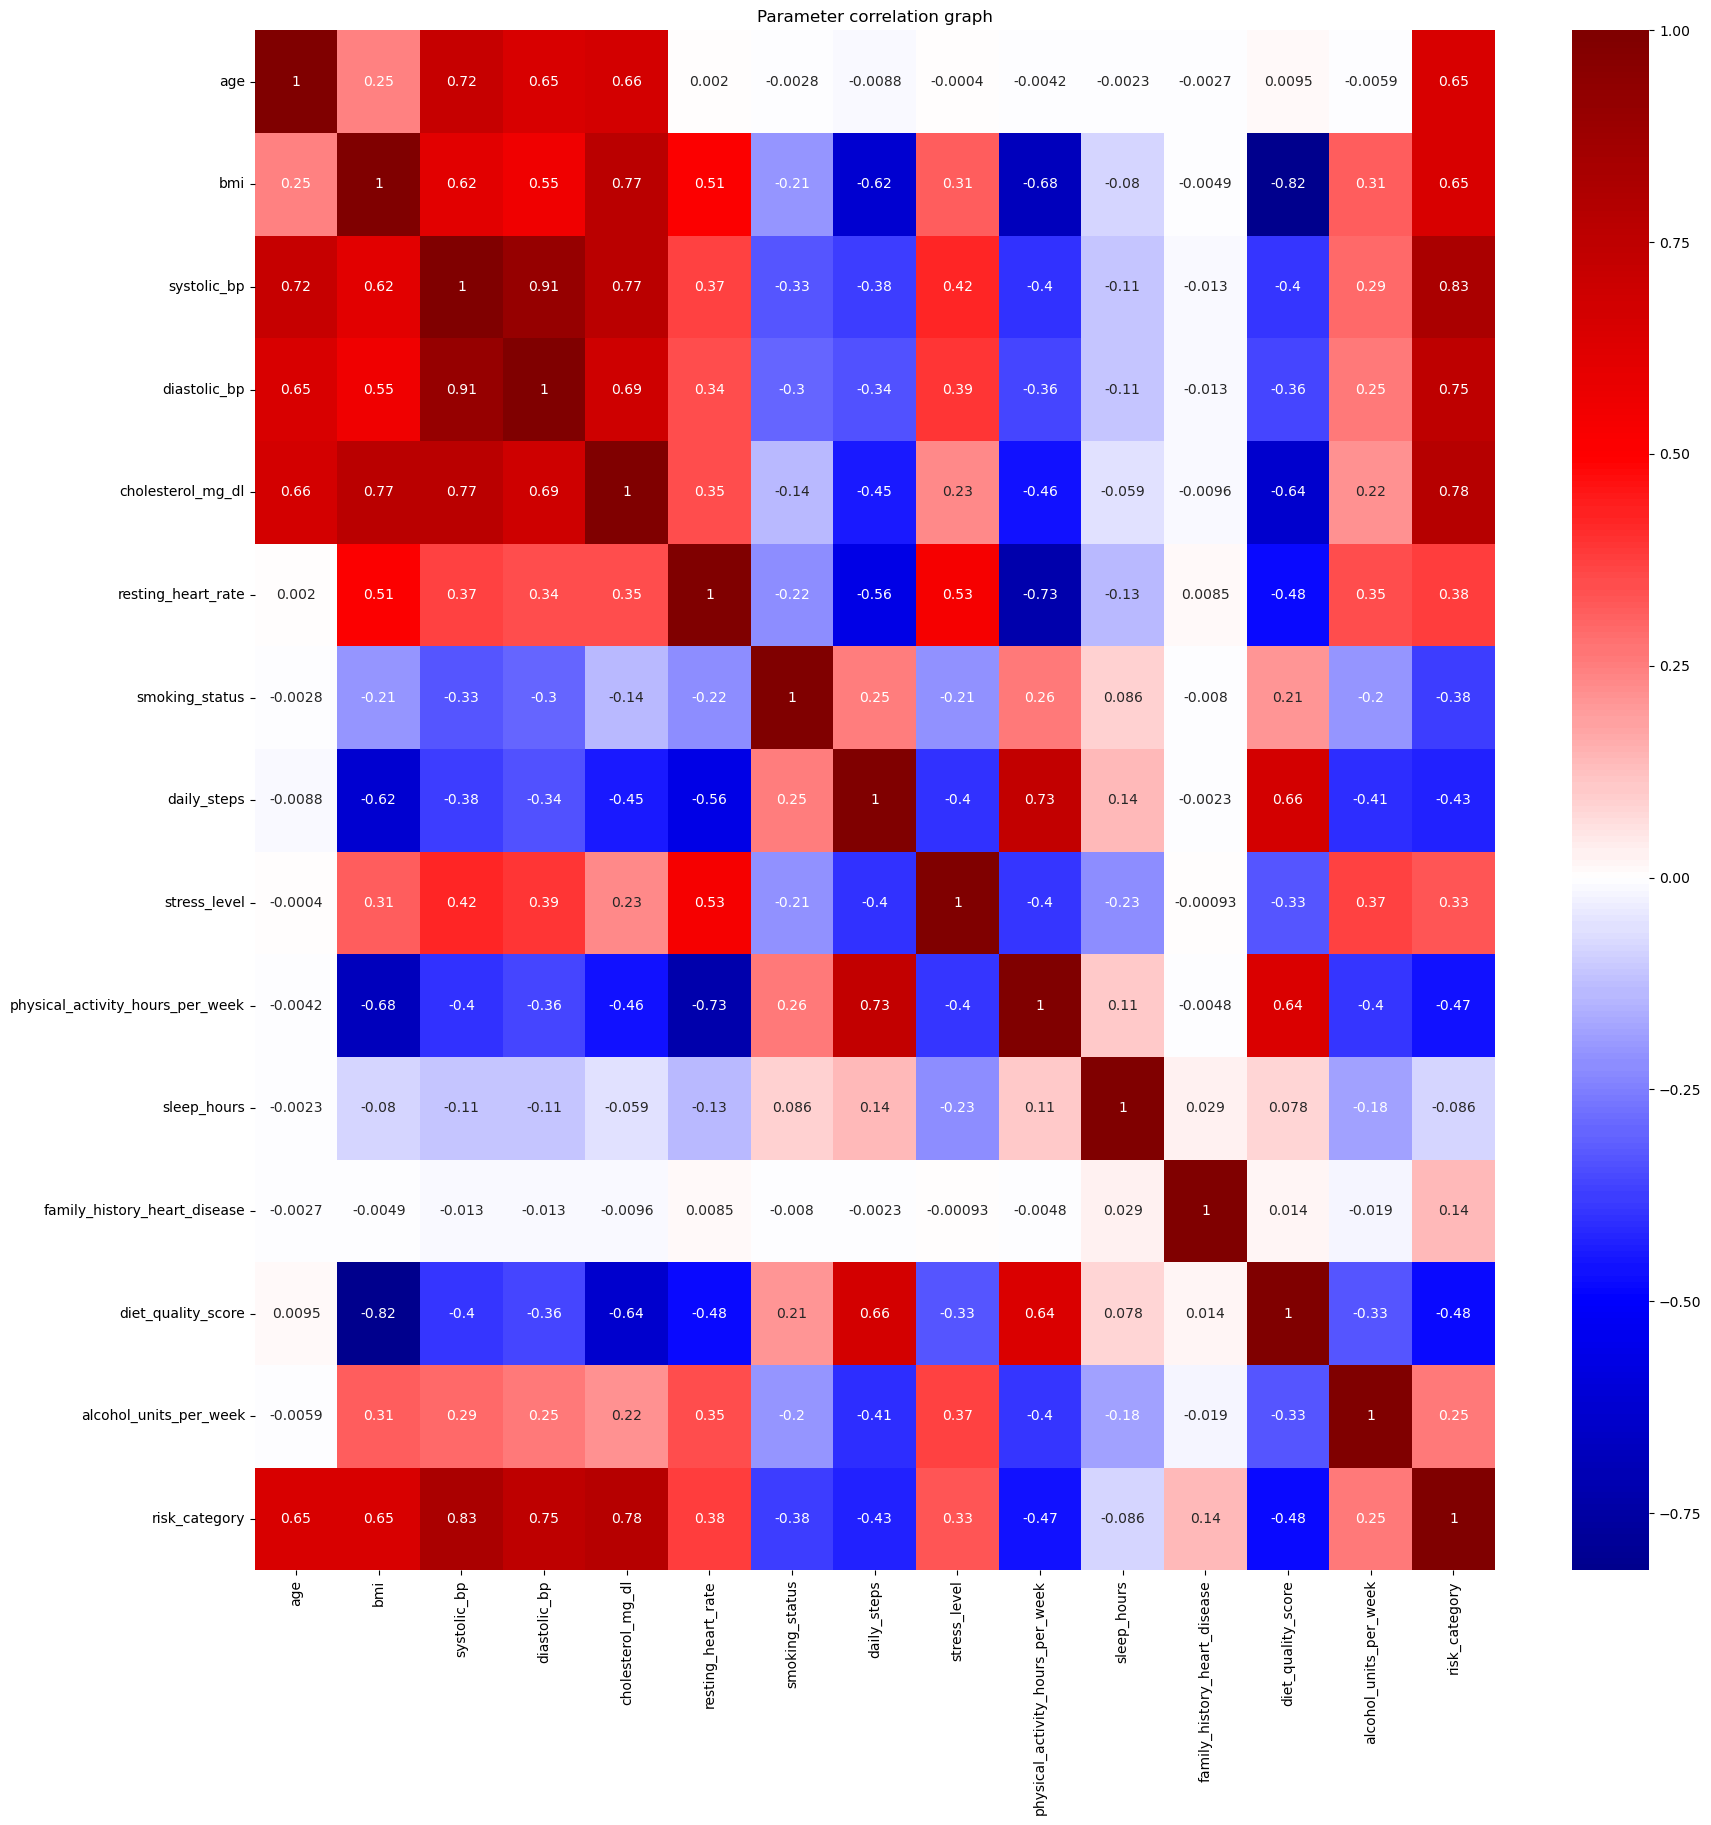

In [53]:
plt.figure(figsize=(20, 20))
seaborn.heatmap(df3.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [75]:
x = df3.drop(['risk_category'], axis = 1).to_numpy()
y = df3['risk_category'].to_numpy()

In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

In [77]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(x_train.shape[1] * 5, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(3, activation='softmax') 
])


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience = 20,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = True
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle=False,
        validation_split = 0.1
        )

train_loss, train_acc = model.evaluate(x_train, y_train)
test_loss, test_acc = model.evaluate(x_test, y_test)
print('\nдля нейронной сети accuracy метрика для обучающей \ тестовой выборки:', train_acc, ' \ ', test_acc)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8712 - loss: 0.3466 
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8848 - loss: 0.3324 

для нейронной сети accuracy метрика для обучающей \ тестовой выборки: 0.8712299466133118  \  0.8848484754562378


In [78]:
# pipline keras

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

class My_Dataset():
    def __init__(self, x, y):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            x, y, test_size=0.15, random_state=42
        )

In [83]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

class NeuralNetworkTrainer(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=2000, batch_size=16, verbose=0, learning_rate=1e-2):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.learning_rate = learning_rate
        self.model = None

    def fit(self, X, y=None):
        input_dim = X.shape[1]
        model = keras.Sequential([
            keras.layers.Dense(x_train.shape[1] * 5, activation='relu', input_shape=(x_train.shape[1],)),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(3, activation='softmax') 
        ])

        model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy']
                        )

        early_stopping = EarlyStopping(
                            monitor='val_loss',
                            patience = 20,
                            min_delta = 0.01,
                            verbose = 0,
                            restore_best_weights = True
                            )

        model.fit(
            x=X,
            y=y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=self.verbose,
            callbacks=[early_stopping],
            shuffle=False,
            validation_split=0.1  # 10% от X пойдёт на валидацию для early stopping
        )

        self.model = model
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)


# Добавьте NeuralNetworkTrainer в ваш конвейер
pipe = Pipeline([
        ('neural_network_trainer', NeuralNetworkTrainer(epochs=2000, batch_size=16, verbose=0))
    ])

# Запустите конвейер на тренировочных данных
pipe.fit(x_train, y_train)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pipeline(steps=[('neural_network_trainer',
                 <__main__.NeuralNetworkTrainer object at 0x000001CA03DEA3C0>)])

In [84]:
train_acc = pipe.score(x_train, y_train)
test_acc = pipe.score(x_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Train accuracy: 0.8631
Test accuracy: 0.8727


C:\Users\User\anaconda3\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
# piplain py torch

In [88]:
import torch
from torch.utils.data import Dataset, DataLoader

class my_Dataset(Dataset):
    
    def __init__(self, features, labels):

        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.long)

        self.mean = self.features.mean(dim=0)
        self.std = self.features.std(dim=0)
        
        self.std[self.std == 0] = 1.0
        self.normalized_features = (self.features - self.mean) / self.std
    
    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.normalized_features[idx], self.labels[idx]

    def get_original(self, idx):
        return self.features[idx], self.labels[idx]

In [89]:
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self, input_size, num_classes=3):
        super().__init__()
        self.layer1 = nn.Linear(input_size, input_size * 5)
        self.act1 = nn.ReLU()
        self.drop = nn.Dropout(0.3)
        self.layer2 = nn.Linear(input_size * 5, input_size)
        self.act2 = nn.ReLU()
        self.last_layer = nn.Linear(input_size, num_classes)  # 3 нейрона

    def forward(self, x):
        x = self.layer1(x)
        x = self.act1(x)
        x = self.drop(x)
        x = self.layer2(x)
        x = self.act2(x)
        x = self.last_layer(x)
        return x 


In [90]:
train_dataset = my_Dataset(x_train, y_train)    
test_dataset = my_Dataset(x_test, y_test)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)


In [94]:
from sklearn.metrics import r2_score

def train_classifier(model, train_loader, num_epochs=2000, learning_rate=1e-3,
                     weight_decay=1e-4, patience=20, min_delta=0.01):
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss()  # для классификации
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=weight_decay)

    history = {'train_loss': [], 'train_acc': []}
    best_acc = -float('inf')
    best_weights = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        all_labels = []
        all_preds = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  
            optimizer.zero_grad()
            outputs = model(inputs)             
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0) 
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

        # Метрики за эпоху
        avg_loss = train_loss / len(train_loader.dataset) 
        acc = accuracy_score(all_labels, all_preds)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(acc)

        # Ранняя остановка по тренировочной accuracy
        if acc > best_acc + min_delta:
            best_acc = acc
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if best_weights is not None:
                    model.load_state_dict(best_weights)
                print(f'\nEarly stopping on epoch {epoch}')
                print(f'Train Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}')
                break

        # Логирование
        if epoch % 10 == 0:
            print(f'\nEpoch {epoch}/{num_epochs}:')
            print(f'Train Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}')

    return model, history

In [95]:
def evaluate_classifier(model, data_loader):
    """
    Оценка точности на данных из data_loader.
    Возвращает accuracy, все предсказания и все истинные метки.
    """
    device = next(model.parameters()).device
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc, np.array(all_preds), np.array(all_labels)

In [96]:
model = Classifier(input_size=x_train.shape[1], num_classes=3)

# Обучаем
trained_model, history = train_classifier(
    model=model,
    train_loader=train_loader,
    num_epochs=2000,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=20,
    min_delta=0.01
)

# Оценка
test_acc, test_preds, test_labels = evaluate_classifier(trained_model, test_loader)
train_acc, train_preds, train_labels = evaluate_classifier(trained_model, train_loader)

print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Epoch 0/2000:
Train Loss: 0.5544, Train Acc: 0.8011

Epoch 10/2000:
Train Loss: 0.1596, Train Acc: 0.9283

Epoch 20/2000:
Train Loss: 0.1433, Train Acc: 0.9358

Epoch 30/2000:
Train Loss: 0.1378, Train Acc: 0.9358

Early stopping on epoch 34
Train Loss: 0.1331, Train Acc: 0.9407

Train accuracy: 0.9491
Test accuracy: 0.9285


In [103]:
# pipline

class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, num_epochs=2000, batch_size=16, learning_rate=1e-3,
                 weight_decay=1e-4, patience=20, min_delta=0.01, verbose=0):
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.model_ = None
        self.history_ = None
        self.classes_ = None
        self.mean_ = None
        self.std_ = None

    def fit(self, X, y):
        # Сохраняем классы
        self.classes_ = np.unique(y)

        # Вычисляем статистики нормализации (на всех тренировочных данных)
        X_t = torch.as_tensor(X, dtype=torch.float32)
        self.mean_ = X_t.mean(dim=0)
        self.std_ = X_t.std(dim=0)
        self.std_[self.std_ == 0] = 1.0

        # Создаём датасет и загрузчик
        train_dataset = my_Dataset(X, y)  # внутри использует свои mean/std, но они совпадут с вычисленными
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        # Создаём модель
        input_size = X.shape[1]
        num_classes = len(self.classes_)
        model = Classifier(input_size, num_classes)

        # Обучаем
        self.model_, self.history_ = train_classifier(
            model, train_loader,
            num_epochs=self.num_epochs,
            learning_rate=self.learning_rate,
            weight_decay=self.weight_decay,
            patience=self.patience,
            min_delta=self.min_delta
        )
        return self

    def predict(self, X):
        if self.model_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit.")
        device = next(self.model_.parameters()).device
        self.model_.eval()

        # Нормализация X с сохранёнными статистиками
        X_t = torch.as_tensor(X, dtype=torch.float32)
        X_norm = (X_t - self.mean_) / self.std_
        X_norm = X_norm.to(device)

        with torch.no_grad():
            outputs = self.model_(X_norm)
            preds = torch.argmax(outputs, dim=1)
        return preds.cpu().numpy()

    def predict_proba(self, X):
        if self.model_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit.")
        device = next(self.model_.parameters()).device
        self.model_.eval()

        X_t = torch.as_tensor(X, dtype=torch.float32)
        X_norm = (X_t - self.mean_) / self.std_
        X_norm = X_norm.to(device)

        with torch.no_grad():
            outputs = self.model_(X_norm)
            probs = torch.softmax(outputs, dim=1)
        return probs.cpu().numpy()

    def score(self, X, y):
        preds = self.predict(X)
        return accuracy_score(y, preds)


In [104]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('pytorch_clf', PyTorchClassifier(
        num_epochs=2000,
        batch_size=16,
        learning_rate=1e-3,
        weight_decay=1e-4,
        patience=20,
        min_delta=0.01
    ))
])

# Обучаем
pipe.fit(x_train, y_train)

# Оцениваем
train_acc = pipe.score(x_train, y_train)
test_acc = pipe.score(x_test, y_test)
print(f'\nTrain accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')


Epoch 0/2000:
Train Loss: 0.5345, Train Acc: 0.7953

Epoch 10/2000:
Train Loss: 0.1676, Train Acc: 0.9249

Epoch 20/2000:
Train Loss: 0.1480, Train Acc: 0.9341

Epoch 30/2000:
Train Loss: 0.1408, Train Acc: 0.9401

Epoch 40/2000:
Train Loss: 0.1369, Train Acc: 0.9386

Early stopping on epoch 48
Train Loss: 0.1289, Train Acc: 0.9418

Train accuracy: 0.9497
Test accuracy: 0.9345
